## Setup

In [1]:
from pathlib import Path
from typing import Optional, Dict, List, Tuple, Any, Literal, Union
import datetime
from dataclasses import dataclass, field
from collections import defaultdict

from rapidfuzz.distance import Levenshtein
import cv2

import jax
from jax import numpy as jnp
from flax.training import train_state, orbax_utils
from flax import linen as nn
import optax
import orbax
from tensorboardX import SummaryWriter
from einops import rearrange, einsum

import albumentations as A

from matplotlib import pyplot as plt

from tqdm import tqdm

key = jax.random.key(0)

W1209 04:44:03.843999   15963 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1209 04:44:03.848721   15018 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


## Model

In [2]:
class RoPE(nn.Module):
    hidden_dim: int
    theta_base: float = 10000

    @nn.compact
    def __call__(self, x: jnp.ndarray, pos_ids: jnp.ndarray) -> jnp.ndarray:
        d = self.hidden_dim
        assert d % 2 == 0

        i = jnp.arange(0, d // 2)
        theta = self.theta_base ** (-2 * i / d)
        angles = pos_ids[:, None, :, None] * theta[None, None, None, :]

        cos = jnp.cos(angles)
        sin = jnp.sin(angles)
        x_pairs = rearrange(x, "b h n (d two) -> b h n d two", two=2)

        x_rotated = jnp.stack([x_pairs[..., 0] * cos - x_pairs[..., 1] * sin, x_pairs[..., 0] * sin + x_pairs[..., 1] * cos], axis=-1)
        x_rotated = rearrange(x_rotated, "b h n d two -> b h n (d two)")

        return x_rotated


class MultiHeadAttention(nn.Module):
    hidden_dim: int
    num_heads: int
    dropout: float = 0.0
    use_rope: bool = False

    @nn.compact
    def __call__(
        self,
        q: jnp.ndarray,
        k: jnp.ndarray,
        v: jnp.ndarray,
        pos_ids: Optional[jnp.ndarray] = None,
        deterministic: bool = False,
        valid_mask: Optional[jnp.ndarray] = None,
        causal: bool = False,
        use_cache: bool = False,
    ) -> jnp.ndarray:
        q = nn.Dense(self.hidden_dim)(q)
        k = nn.Dense(self.hidden_dim)(k)
        v = nn.Dense(self.hidden_dim)(v)

        q = rearrange(q, "b n (h d) -> b h n d", h=self.num_heads)
        k = rearrange(k, "b n (h d) -> b h n d", h=self.num_heads)
        v = rearrange(v, "b n (h d) -> b h n d", h=self.num_heads)

        head_dim = self.hidden_dim // self.num_heads
        if self.use_rope:
            assert pos_ids is not None
            rope = RoPE(hidden_dim=head_dim)
            q = rope(q, pos_ids)
            k = rope(k, pos_ids)

        if use_cache:
            assert self.is_mutable_collection("kv_cache")
            k_cache = self.variables.get("kv_cache", {}).get("k", None)
            v_cache = self.variables.get("kv_cache", {}).get("v", None)
            if k_cache is not None:
                k = jnp.concatenate([k_cache, k], axis=2)
                v = jnp.concatenate([v_cache, v], axis=2)

            self.put_variable("kv_cache", "k", k)
            self.put_variable("kv_cache", "v", v)

        attn_weights = einsum(q, k, "b h i d, b h j d -> b h i j") / jnp.sqrt(head_dim)

        b, _, i, j = attn_weights.shape
        mask = jnp.zeros((b, 1, i, j), dtype=jnp.bool)
        if valid_mask is not None:
            padding_mask = ~valid_mask[:, None, None, :]
            mask = mask | padding_mask
        if causal:
            causal_mask = jnp.triu(jnp.ones((1, 1, i, j), dtype=jnp.bool), k=j - i + 1)
            mask = mask | causal_mask
        attn_weights = jnp.where(mask, jnp.finfo(attn_weights.dtype).min, attn_weights)
        attn_weights = jax.nn.softmax(attn_weights, axis=-1)
        attn_weights = nn.Dropout(rate=self.dropout)(attn_weights, deterministic=deterministic)

        out = einsum(attn_weights, v, "b h i j, b h j d -> b h i d")
        out = rearrange(out, "b h n d -> b n (h d)")

        return out


class SelfAttentionBlock(nn.Module):
    hidden_dim: int
    num_heads: int
    dropout: float = 0.0
    ffn_scale: float = 2.0
    use_rope: bool = False

    @nn.compact
    def __call__(
        self,
        x: jnp.ndarray,
        pos_ids: Optional[jnp.ndarray] = None,
        deterministic: bool = False,
        valid_mask: Optional[jnp.ndarray] = None,
        causal: bool = False,
        use_cache: bool = False,
    ) -> jnp.ndarray:
        x_normed = nn.LayerNorm()(x)
        x = (
            MultiHeadAttention(self.hidden_dim, self.num_heads, self.dropout, use_rope=self.use_rope)(
                q=x_normed,
                k=x_normed,
                v=x_normed,
                pos_ids=pos_ids,
                deterministic=deterministic,
                valid_mask=valid_mask,
                causal=causal,
                use_cache=use_cache,
            )
            + x
        )
        return nn.Sequential([nn.Dense(int(self.hidden_dim * self.ffn_scale)), nn.gelu, nn.Dense(self.hidden_dim)])(nn.LayerNorm()(x)) + x


class CrossAttentionBlock(nn.Module):
    hidden_dim: int
    num_heads: int
    dropout: float = 0.0
    ffn_scale: float = 2.0

    @nn.compact
    def __call__(self, x: jnp.ndarray, c: jnp.ndarray, deterministic: bool = False) -> jnp.ndarray:
        x_normed = nn.LayerNorm()(x)
        c_normed = nn.LayerNorm()(c)
        x = (
            MultiHeadAttention(self.hidden_dim, self.num_heads, self.dropout, use_rope=False)(
                q=x_normed,
                k=c_normed,
                v=c_normed,
                deterministic=deterministic,
            )
            + x
        )
        return nn.Sequential([nn.Dense(int(self.hidden_dim * self.ffn_scale)), nn.gelu, nn.Dense(self.hidden_dim)])(nn.LayerNorm()(x)) + x


class GRUEncoder(nn.Module):
    patch_size: int
    num_layers: int
    hidden_dim: int
    dropout: float = 0.0

    @nn.compact
    def __call__(self, img: jnp.ndarray, deterministic: bool = False) -> jnp.ndarray:
        b, *_ = img.shape
        x = rearrange(img, "b c h w -> b h w c")
        x = nn.Conv(
            features=self.hidden_dim * 2, kernel_size=(self.patch_size, self.patch_size), strides=(self.patch_size, self.patch_size), padding="VALID"
        )(x)
        x_seq = rearrange(x, "b h w d -> (h w) b d")
        GRU = nn.scan(nn.GRUCell, variable_broadcast="params", split_rngs={"params": False}, in_axes=0, out_axes=0)

        for _ in range(self.num_layers):
            fwd = GRU(self.hidden_dim)
            bwd = GRU(self.hidden_dim)

            _, x_fwd = fwd(jnp.zeros((b, self.hidden_dim)), x_seq)
            _, x_bwd = bwd(jnp.zeros((b, self.hidden_dim)), x_seq[::-1])

            x_bwd = x_bwd[::-1]
            x_seq = jnp.concatenate([x_fwd, x_bwd], axis=-1)
            x_seq = nn.Dropout(rate=self.dropout)(nn.gelu(x_seq), deterministic=deterministic)

        x = nn.Dense(self.hidden_dim)(x_seq)
        x = rearrange(x, "c b d -> b c d")

        return x


class ViTEncoder(nn.Module):
    patch_size: int
    num_layers: int
    hidden_dim: int
    num_heads: int
    dropout: float = 0.0
    ffn_scale: float = 2.0
    add_cls_token: bool = True
    use_rope: bool = False

    @nn.compact
    def __call__(self, img: jnp.ndarray, deterministic: bool = False) -> jnp.ndarray:
        b, *_ = img.shape

        x = rearrange(img, "b c h w -> b h w c")
        x = nn.Conv(
            features=self.hidden_dim,
            kernel_size=(self.patch_size, self.patch_size),
            strides=(self.patch_size, self.patch_size),
            padding="VALID",
        )(x)
        x = rearrange(x, "b hp wp d -> b (hp wp) d")

        if self.add_cls_token:
            cls_token = self.param(
                "cls_token",
                nn.initializers.normal(stddev=0.02),
                (1, 1, self.hidden_dim),
            )
            cls_token = jnp.broadcast_to(cls_token, (b, 1, self.hidden_dim))
            x = jnp.concatenate([cls_token, x], axis=1)

        seq_len = x.shape[1]
        pos_ids = jnp.broadcast_to(jnp.arange(0, seq_len)[None, :], (b, seq_len))

        for _ in range(self.num_layers):
            x = SelfAttentionBlock(
                hidden_dim=self.hidden_dim,
                num_heads=self.num_heads,
                dropout=self.dropout,
                ffn_scale=self.ffn_scale,
                use_rope=self.use_rope,
            )(x=x, pos_ids=pos_ids, deterministic=deterministic)

        x = nn.LayerNorm()(x)
        return x


class AutoregressiveTransformerDecoder(nn.Module):
    vocab_size: int
    num_layers: int
    hidden_dim: int
    num_heads: int
    dropout: float = 0.0
    ffn_scale: float = 2.0
    use_rope: bool = False

    @nn.compact
    def __call__(
        self,
        input_ids: jnp.ndarray,
        c: jnp.ndarray,
        pos_ids: jnp.ndarray,
        deterministic: bool = False,
        valid_mask: Optional[jnp.ndarray] = None,
        use_cache: bool = False,
    ) -> jnp.ndarray:
        x = nn.Embed(self.vocab_size, self.hidden_dim)(input_ids)
        for _ in range(self.num_layers):
            x = SelfAttentionBlock(
                hidden_dim=self.hidden_dim,
                num_heads=self.num_heads,
                dropout=self.dropout,
                ffn_scale=self.ffn_scale,
                use_rope=self.use_rope,
            )(x=x, pos_ids=pos_ids, deterministic=deterministic, valid_mask=valid_mask, causal=True, use_cache=use_cache)
            x = CrossAttentionBlock(
                hidden_dim=self.hidden_dim,
                num_heads=self.num_heads,
                dropout=self.dropout,
                ffn_scale=self.ffn_scale,
            )(x=x, c=c, deterministic=deterministic)

        logits = nn.Dense(self.vocab_size)(x)
        return logits


class TransformerOCRTrainWrapper(nn.Module):
    encoder: Union[ViTEncoder, GRUEncoder]
    decoder: AutoregressiveTransformerDecoder

    @nn.compact
    def __call__(
        self, img: jnp.ndarray, input_ids: jnp.ndarray, valid_mask: Optional[jnp.ndarray] = None, deterministic: bool = False
    ) -> jnp.ndarray:
        ctx = self.encoder(img, deterministic=deterministic)
        b, n = input_ids.shape
        pos_ids = jnp.broadcast_to(jnp.arange(0, n)[None, :], (b, n))
        out = self.decoder(input_ids, ctx, pos_ids, deterministic=deterministic, valid_mask=valid_mask)

        return out

## Sanity Check

In [3]:
encoder = ViTEncoder(patch_size=16, num_layers=2, hidden_dim=128, num_heads=4, dropout=0.1, ffn_scale=4.0, use_rope=True)
img = jnp.zeros((1, 3, 56, 280), dtype=jnp.float32)
key, subkey = jax.random.split(key)
params = encoder.init(subkey, img)

ctx = encoder.apply(params, img, deterministic=True)
print(f"ctx shape: {ctx.shape}")

decoder = AutoregressiveTransformerDecoder(vocab_size=24, num_layers=2, hidden_dim=128, num_heads=4, dropout=0.1, ffn_scale=4.0, use_rope=True)
input_ids = jnp.zeros((1, 10), dtype=jnp.int32)
pos_ids = jnp.arange(0, input_ids.shape[1])[None, :].repeat(1, axis=0)
key, subkey = jax.random.split(key)
params = decoder.init(subkey, input_ids, ctx, pos_ids)

logits = decoder.apply(params, input_ids, ctx, pos_ids, deterministic=True)
print(f"logits shape: {logits.shape}")


wrapper = TransformerOCRTrainWrapper(encoder, decoder)
valid_mask = jnp.ones((1, 10), dtype=jnp.bool)
params = wrapper.init(subkey, img, input_ids, valid_mask=valid_mask)

logits_wrapper = wrapper.apply(params, img, input_ids, valid_mask=valid_mask, deterministic=True)
print(f"logits_wrapper shape: {logits_wrapper.shape}")

ctx shape: (1, 52, 128)
logits shape: (1, 10, 24)
logits_wrapper shape: (1, 10, 24)


## Data

In [4]:
import numpy as np
import grain.python as grain
import grain.transforms as grain_transforms


class OCRDataSource(grain.RandomAccessDataSource):
    def __init__(self, image_paths: List[str]):
        self.image_paths = list(map(Path, image_paths))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label_str = path.stem.split("_")[-1]
        return {"path": str(path), "label_str": label_str}


class LoadAndTransform(grain_transforms.Map):
    def __init__(self, transform: Optional[A.Compose], vocab_dict: Dict[str, int], max_length: int):
        super().__init__()
        self.transform = transform
        self.vocab_dict = vocab_dict
        self.max_length = max_length
        self.pad_token_id = vocab_dict["<eos>"]
        self.bos_token_id = vocab_dict["<bos>"]
        self.eos_token_id = vocab_dict["<eos>"]

    def map(self, record):
        image = cv2.imread(record["path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)["image"]
            image = np.array(image, dtype=np.float32)
        else:
            image = np.array(image, dtype=np.float32) / 255.0
        image = image.transpose(2, 0, 1)
        label_str = record["label_str"]
        label_ids = [self.bos_token_id] + [self.vocab_dict[c] for c in label_str] + [self.eos_token_id]
        length = len(label_ids)
        if length > self.max_length:
            label_ids = label_ids[: self.max_length]
            length = self.max_length
        padded_label = label_ids + [self.pad_token_id] * (self.max_length - length)
        padded_label = np.array(padded_label, dtype=np.int32)
        valid_mask = np.zeros((self.max_length,), dtype=bool)
        valid_mask[:length] = True
        return {"image": image, "label": padded_label, "valid_mask": valid_mask}


def create_loader(
    paths: List[str],
    vocab_dict: Dict[str, int],
    transform: Optional[A.Compose],
    batch_size: int,
    max_length: int,
    shuffle: bool = True,
    seed: int = 42,
    num_workers: int = 4,
    worker_buffer_size: int = 1,
    num_epochs: Optional[int] = None,
):
    source = OCRDataSource(paths)
    sampler = grain.IndexSampler(num_records=len(source), shuffle=shuffle, seed=seed, shard_options=grain.NoSharding(), num_epochs=num_epochs)
    loader = grain.DataLoader(
        data_source=source,
        sampler=sampler,
        worker_count=num_workers,
        worker_buffer_size=worker_buffer_size,
        operations=[
            LoadAndTransform(transform, vocab_dict, max_length),
            grain_transforms.Batch(batch_size=batch_size, drop_remainder=True),
        ],
    )

    return loader


def get_vocab(root_dir: str) -> Dict[str, int]:
    vocab = set()
    for path in Path(root_dir).glob("**/*.png"):
        vocab.update(path.stem.split("_")[-1])
    vocab_list = ["<bos>", "<eos>"] + sorted(list(vocab))
    vocab_dict = {char: i for i, char in enumerate(vocab_list)}
    return vocab_dict


def distance(pred: jnp.ndarray, target: jnp.ndarray, ignore_tokens: List[int]) -> int:
    assert pred.ndim == 1 and target.ndim == 1
    ignore_tokens = jnp.array(ignore_tokens)
    return Levenshtein.distance(pred[~jnp.isin(pred, ignore_tokens)].tolist(), target[~jnp.isin(target, ignore_tokens)].tolist())


max_length = 16
size = (56, 280)
mean = (0.5, 0.5, 0.5)
std = (0.5, 0.5, 0.5)

train_transform = A.Compose(
    [
        A.Resize(*size, interpolation=cv2.INTER_AREA),
        A.OneOf(
            [
                A.MotionBlur(blur_limit=7),
                A.GaussianBlur(blur_limit=(3, 7)),
                A.MedianBlur(blur_limit=5),
            ],
            p=0.5,
        ),
        A.OneOf(
            [
                A.Affine(
                    scale=(0.9, 1.1),
                    translate_percent=(0.02, 0.08),
                    rotate=(-5, 5),
                    shear=(-5, 5),
                    fit_output=False,
                    interpolation=cv2.BORDER_CONSTANT,
                ),
                A.Perspective(scale=(0.02, 0.08), keep_size=True),
                A.ElasticTransform(),
                A.GridDistortion(num_steps=5, distort_limit=0.2),
            ],
            p=0.7,
        ),
        A.OneOf(
            [
                A.ColorJitter(0.3, 0.3, 0.3, 0.1),
                A.RandomBrightnessContrast(0.3, 0.3),
                A.CLAHE(clip_limit=3.0),
                A.ToGray(),
            ],
            p=0.6,
        ),
        A.OneOf(
            [
                A.ISONoise(color_shift=(0.01, 0.07), intensity=(0.1, 0.6)),
                A.MultiplicativeNoise(multiplier=(0.8, 1.2), per_channel=True),
                A.GaussNoise(std_range=(0.2, 0.4)),
            ],
            p=0.4,
        ),
        A.CoarseDropout(
            num_holes_range=(1, 3),
            hole_height_range=(10, 20),
            hole_width_range=(10, 20),
            fill=0,
            p=0.3,
        ),
        A.ImageCompression(quality_range=(40, 95), p=0.3),
        A.Normalize(mean=mean, std=std),
    ]
)

val_transform = A.Compose(
    [
        A.Resize(*size, interpolation=cv2.INTER_AREA),
        A.Normalize(mean=mean, std=std),
    ]
)

all_paths = list(Path("data/train").glob("**/*.png"))
key, subkey = jax.random.split(key)
ids = jax.random.permutation(subkey, jnp.arange(len(all_paths)))
train_paths = all_paths[: int(len(all_paths) * 0.8)]
val_paths = all_paths[int(len(all_paths) * 0.8) :]


## Visualization

In [5]:
vocab_dict = get_vocab("data/train")
loader = create_loader(train_paths, vocab_dict, train_transform, 4, max_length)

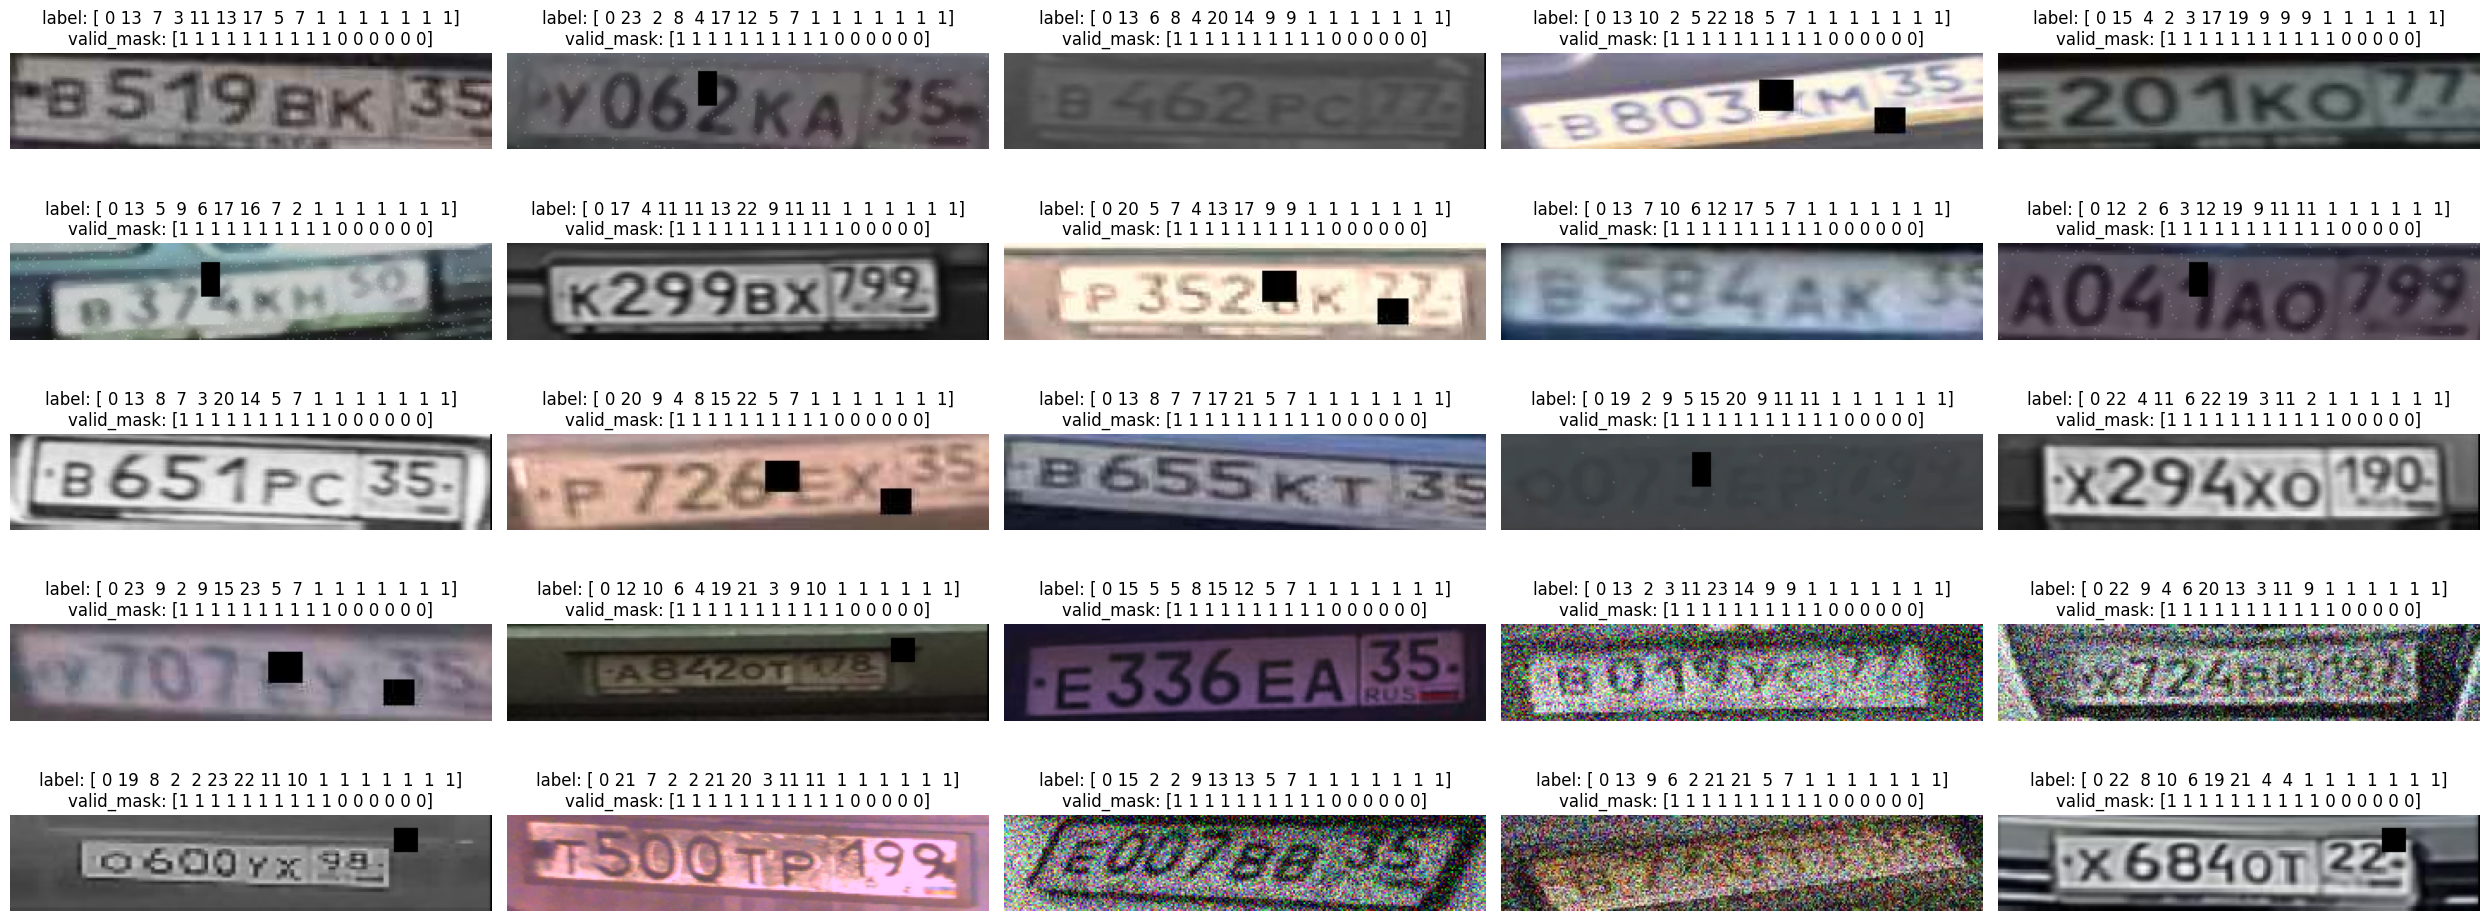

In [6]:
images_set = []
labels_set = []
valid_masks_set = []
should_break = False
for batch in loader:
    for image, label, valid_mask in zip(batch["image"], batch["label"], batch["valid_mask"]):
        images_set.append(image)
        labels_set.append(label)
        valid_masks_set.append(valid_mask)
        if len(images_set) >= 25:
            should_break = True
            break
    if should_break:
        break

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(25, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    image, label, valid_mask = images_set[i], labels_set[i], valid_masks_set[i]
    ax.imshow(image.transpose(1, 2, 0) / 2 + 0.5)
    ax.set_title(f"label: {label}\nvalid_mask: {valid_mask.astype(int)}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Training

In [7]:
@dataclass
class TrainConfig:
    exp_name: str = "default"
    encoder_type: Literal["vit", "rnn"] = "vit"
    encoder_kwargs: Dict[str, Any] = field(default_factory=lambda: {})
    decoder_kwargs: Dict[str, Any] = field(default_factory=lambda: {})
    num_epochs: int = 50
    steps_per_epoch: int = 2000
    max_grad_norm: float = 1.0
    lr: float = 1e-2
    weight_decay: float = 0.0
    data_root: str = "data/train"
    val_split_size: float = 0.2
    vocab_dict: Dict[str, int] = field(default_factory=lambda: get_vocab("data/train"))
    train_batch_size: int = 128
    val_batch_size: int = 128
    train_transform: Optional[A.Compose] = None
    val_transform: Optional[A.Compose] = None
    max_length: int = 16
    num_beams: int = 5
    dataloader_num_workers: int = 4
    dataloader_worker_buffer_size: int = 1
    resume_ckpt_path: Optional[str] = None


class OCRTrainState(train_state.TrainState):
    global_step: int
    key: jax.Array


@jax.jit
def cross_entropy(logits: jnp.ndarray, targets: jnp.ndarray, valid_mask: jnp.ndarray) -> jnp.ndarray:
    targets_ohe = jax.nn.one_hot(targets, logits.shape[-1])
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    losses = -jnp.sum(targets_ohe * log_probs, axis=-1)
    return jnp.sum(losses * valid_mask) / jnp.sum(valid_mask)


@jax.jit
def entropy_fn(logits: jnp.ndarray) -> jnp.ndarray:
    probs = jax.nn.softmax(logits, axis=-1)
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    return jnp.mean(-jnp.sum(probs * log_probs, axis=-1))


def decode(
    ocr: TransformerOCRTrainWrapper,
    params: Dict[str, Any],
    images: jnp.ndarray,
    max_length: int,
    key: jax.Array,
    bos_token_id: int,
    eos_token_id: int,
    greedy: bool = True,
) -> Tuple[jnp.ndarray, jnp.ndarray]:
    b, *_ = images.shape
    encoder = ocr.encoder
    decoder = ocr.decoder
    decoded_seq = jnp.full((b, 1), bos_token_id, dtype=jnp.int32)
    pos_ids = jnp.broadcast_to(jnp.arange(0, max_length)[None, :, None], (b, max_length, 1))
    encoder_params = {"params": params["params"]["encoder"]}
    ctx = encoder.apply(encoder_params, images, deterministic=True)
    decoder_params = {"params": params["params"]["decoder"]}
    finished = jnp.zeros((b,), dtype=jnp.bool)
    all_logits = []

    for i in range(max_length):
        logits, updated_params = decoder.apply(
            decoder_params, input_ids=decoded_seq[:, -1:], c=ctx, pos_ids=pos_ids[:, i], deterministic=True, use_cache=True, mutable=["kv_cache"]
        )
        decoder_params["kv_cache"] = updated_params["kv_cache"]
        if greedy:
            next_token = jnp.argmax(logits[..., -1, :], axis=-1)
        else:
            next_token = jax.random.categorical(key, logits[..., -1, :], axis=-1)
        finished = finished | (next_token == eos_token_id)
        next_token = jax.lax.select(finished, jnp.full_like(next_token, eos_token_id), next_token)[..., None]
        decoded_seq = jnp.concatenate([decoded_seq, next_token], axis=1)
        all_logits.append(logits)

    all_logits = jnp.concatenate(all_logits, axis=1)
    return decoded_seq[:, 1:], all_logits


def decode_beam_search(
    ocr: TransformerOCRTrainWrapper,
    params: Dict[str, Any],
    images: jnp.ndarray,
    max_length: int,
    bos_token_id: int,
    eos_token_id: int,
    num_beams: int,
) -> Tuple[jnp.ndarray, jnp.ndarray]:
    b, *_ = images.shape
    encoder = ocr.encoder
    decoder = ocr.decoder

    encoder_params = {"params": params["params"]["encoder"]}
    decoder_params = {"params": params["params"]["decoder"]}

    ctx = encoder.apply(encoder_params, images, deterministic=True)

    init_input = jnp.full((b, 1), bos_token_id, dtype=jnp.int32)
    pos_ids = jnp.zeros((b, 1), dtype=jnp.int32)

    logits0 = decoder.apply(
        decoder_params,
        input_ids=init_input,
        c=ctx,
        pos_ids=pos_ids,
        deterministic=True,
    )
    logits0_step = logits0[:, -1, :]
    vocab_size = logits0_step.shape[-1]

    log_probs0 = jax.nn.log_softmax(logits0_step, axis=-1)
    top_log_probs, top_indices = jax.lax.top_k(log_probs0, k=num_beams)

    bos_column = jnp.full((b, num_beams, 1), bos_token_id, dtype=jnp.int32)
    first_tokens = top_indices[..., None]
    sequences = jnp.concatenate([bos_column, first_tokens], axis=-1)

    beam_scores = top_log_probs
    finished = top_indices == eos_token_id

    logits0_for_beams = jnp.repeat(logits0_step[:, None, :], repeats=num_beams, axis=1)
    all_step_logits = [logits0_for_beams]

    ctx_beam = jnp.repeat(ctx, repeats=num_beams, axis=0)

    sequences_flat = sequences.reshape(b * num_beams, sequences.shape[-1])
    beam_scores_flat = beam_scores.reshape(b * num_beams)
    finished_flat = finished.reshape(b * num_beams)

    batch_indices = jnp.arange(b)[:, None]

    for _ in range(1, max_length):
        seq_len = sequences_flat.shape[1]

        pos_ids = jnp.broadcast_to(
            jnp.arange(seq_len, dtype=jnp.int32)[None, :],
            (b * num_beams, seq_len),
        )

        logits = decoder.apply(
            decoder_params,
            input_ids=sequences_flat,
            c=ctx_beam,
            pos_ids=pos_ids,
            deterministic=True,
        )
        logits_step = logits[:, -1, :]

        log_probs = jax.nn.log_softmax(logits_step, axis=-1)

        eos_log_probs = jnp.full_like(log_probs, -1e9)
        eos_log_probs = eos_log_probs.at[:, eos_token_id].set(0.0)
        log_probs = jnp.where(finished_flat[:, None], eos_log_probs, log_probs)

        log_probs_reshaped = log_probs.reshape(b, num_beams, vocab_size)
        beam_scores_reshaped = beam_scores_flat.reshape(b, num_beams, 1)
        candidate_scores = beam_scores_reshaped + log_probs_reshaped

        candidate_scores_flat = candidate_scores.reshape(b, num_beams * vocab_size)
        top_scores, top_indices = jax.lax.top_k(candidate_scores_flat, k=num_beams)

        beam_idx = top_indices // vocab_size
        token_idx = top_indices % vocab_size

        sequences_reshaped = sequences_flat.reshape(b, num_beams, seq_len)
        chosen_sequences = sequences_reshaped[batch_indices, beam_idx, :]

        finished_reshaped = finished_flat.reshape(b, num_beams)
        chosen_finished = finished_reshaped[batch_indices, beam_idx]

        logits_step_reshaped = logits_step.reshape(b, num_beams, vocab_size)
        chosen_logits_step = logits_step_reshaped[batch_indices, beam_idx, :]

        new_sequences = jnp.concatenate([chosen_sequences, token_idx[..., None]], axis=-1)
        new_finished = jnp.logical_or(chosen_finished, token_idx == eos_token_id)

        beam_scores = top_scores
        sequences_flat = new_sequences.reshape(b * num_beams, new_sequences.shape[-1])
        finished_flat = new_finished.reshape(b * num_beams)
        beam_scores_flat = beam_scores.reshape(b * num_beams)

        all_step_logits.append(chosen_logits_step)

    sequences = sequences_flat.reshape(b, num_beams, max_length + 1)
    all_logits = jnp.stack(all_step_logits, axis=2)

    return sequences[:, 0, 1:], all_logits[:, 0, :, :]


@jax.jit
def train_step(state: OCRTrainState, batch: Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]) -> OCRTrainState:
    images = batch["image"]
    labels = batch["label"]
    valid_masks = batch["valid_mask"]

    input_ids = labels[:, :-1]
    valid_mask = valid_masks[:, :-1]
    targets = labels[:, 1:]
    key, subkey = jax.random.split(state.key)

    def loss_fn(params):
        logits = state.apply_fn(params, images, input_ids, valid_mask=valid_mask, rngs={"dropout": subkey})
        loss = cross_entropy(logits, targets, valid_mask)
        return loss, logits

    (loss, logits), grads = jax.value_and_grad(loss_fn, has_aux=True)(state.params)
    state = state.apply_gradients(grads=grads, key=key, global_step=state.global_step + 1)
    return state, loss, logits


@jax.jit(static_argnames=["ocr", "num_beams", "bos_token_id", "eos_token_id"])
def eval_step(
    ocr: TransformerOCRTrainWrapper,
    state: OCRTrainState,
    batch: Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray],
    key: jax.Array,
    bos_token_id: int,
    eos_token_id: int,
    num_beams: int = 5,
):
    images = batch["image"]
    labels = batch["label"]
    valid_masks = batch["valid_mask"]

    input_ids = labels[:, :-1]
    valid_mask = valid_masks[:, :-1]
    targets = labels[:, 1:]
    logits_forward = ocr.apply(state.params, images, input_ids, valid_mask=valid_mask, deterministic=True)
    loss = cross_entropy(logits_forward, targets, valid_mask)
    key, subkey = jax.random.split(key)
    decoded_seq_greedy, logits_greedy = decode(ocr, state.params, images, labels.shape[1], subkey, bos_token_id, eos_token_id, greedy=True)
    key, subkey = jax.random.split(key)
    decoded_seq_fair, logits_fair = decode(ocr, state.params, images, labels.shape[1], subkey, bos_token_id, eos_token_id, greedy=False)
    decoded_seq_beam_search, logits_beam_search = decode_beam_search(
        ocr, state.params, images, labels.shape[1], bos_token_id, eos_token_id, num_beams=num_beams
    )

    return (
        loss,
        logits_forward,
        decoded_seq_greedy,
        logits_greedy,
        decoded_seq_fair,
        logits_fair,
        decoded_seq_beam_search,
        logits_beam_search,
    )


def train(key: jax.Array, config: TrainConfig):
    experiment_name = f"{config.exp_name}-{datetime.datetime.now().strftime('%Y-%m-%d-%H-%M-%S')}"
    log_dir = Path(f"logs/{experiment_name}")
    ckpt_dir = log_dir / "checkpoints"
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    vocab_dict = config.vocab_dict

    all_paths = list(Path(config.data_root).glob("**/*.png"))
    key, subkey = jax.random.split(key)
    ids = jax.random.permutation(subkey, jnp.arange(len(all_paths)))
    all_paths_shuffled = list(map(lambda i: all_paths[ids[i]], range(len(all_paths))))
    train_paths = all_paths_shuffled[: int(len(all_paths) * (1 - config.val_split_size))]
    val_paths = all_paths_shuffled[int(len(all_paths) * (1 - config.val_split_size)) :]

    train_loader = create_loader(
        train_paths,
        vocab_dict,
        config.train_transform,
        config.train_batch_size,
        config.max_length,
        num_workers=config.dataloader_num_workers,
        worker_buffer_size=config.dataloader_worker_buffer_size,
        num_epochs=None,
    )
    val_loader = create_loader(
        val_paths,
        vocab_dict,
        config.val_transform,
        config.val_batch_size,
        config.max_length,
        num_workers=config.dataloader_num_workers,
        worker_buffer_size=config.dataloader_worker_buffer_size,
        num_epochs=1,
    )

    if config.encoder_type == "vit":
        encoder = ViTEncoder(**config.encoder_kwargs)
    elif config.encoder_type == "rnn":
        encoder = GRUEncoder(**config.encoder_kwargs)
    else:
        raise ValueError(f"Invalid encoder type: {config.encoder_type}")
    decoder = AutoregressiveTransformerDecoder(**config.decoder_kwargs)
    ocr = TransformerOCRTrainWrapper(encoder, decoder)

    batch = next(iter(train_loader))

    key, subkey = jax.random.split(key)
    params = ocr.init(subkey, batch["image"], input_ids=batch["label"][:, :-1], valid_mask=batch["valid_mask"][:, :-1])

    num_params = sum([param.size for param in jax.tree_util.tree_leaves(params)])
    print(f"Number of parameters: {num_params}")

    tx = optax.chain(optax.adaptive_grad_clip(config.max_grad_norm), optax.contrib.muon(config.lr, weight_decay=config.weight_decay))
    key, subkey = jax.random.split(key)

    ts = OCRTrainState.create(
        apply_fn=jax.jit(ocr.apply, static_argnames=["deterministic"]),
        params=params,
        tx=tx,
        key=subkey,
        global_step=0,
    )

    orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()
    checkpoint_options = orbax.checkpoint.CheckpointManagerOptions(max_to_keep=3, create=True)
    checkpoint_manager = orbax.checkpoint.CheckpointManager(ckpt_dir.absolute(), orbax_checkpointer, options=checkpoint_options)
    if config.resume_ckpt_path:
        print(f"Resuming from checkpoint: {config.resume_ckpt_path}")
        resume_manager = orbax.checkpoint.CheckpointManager(Path(config.resume_ckpt_path).absolute(), orbax_checkpointer)
        step = resume_manager.latest_step()
        if step is not None:
            ts = resume_manager.restore(step, items=ts)
            print(f"Restored step {step}")
        else:
            print("No checkpoints found in provided path!")

    writer = SummaryWriter(log_dir)

    for epoch in range(config.num_epochs):
        train_iter = iter(train_loader)
        for _ in tqdm(range(config.steps_per_epoch), desc=f"Train Epoch [{epoch + 1:03d}/{config.num_epochs:03d}]"):
            batch = next(train_iter)
            ts, loss, logits = train_step(ts, batch)
            entropy = entropy_fn(logits)
            writer.add_scalar("train/loss", loss.item(), ts.global_step)
            writer.add_scalar("train/entropy", entropy.item(), ts.global_step)
        del train_iter

        metrics = defaultdict(list)
        for batch in tqdm(val_loader, desc=f"Val Epoch [{epoch + 1:03d}/{config.num_epochs:03d}]"):
            key, subkey = jax.random.split(key)
            loss, logits_forward, seq_greedy, logits_greedy, seq_fair, logits_fair, seq_beam_search, logits_beam_search = eval_step(
                ocr, ts, batch, subkey, vocab_dict["<bos>"], vocab_dict["<eos>"], config.num_beams
            )
            labels = batch["label"]
            bos_token_id = vocab_dict["<bos>"]
            eos_token_id = vocab_dict["<eos>"]
            distances_greedy = list(map(lambda pred, target: distance(pred, target, [bos_token_id, eos_token_id]), seq_greedy, labels))
            distances_fair = list(map(lambda pred, target: distance(pred, target, [bos_token_id, eos_token_id]), seq_fair, labels))
            distances_beam_search = list(map(lambda pred, target: distance(pred, target, [bos_token_id, eos_token_id]), seq_beam_search, labels))
            metrics["loss"].append(loss)
            metrics["entropy_forward"].append(entropy_fn(logits_forward))
            metrics["distances_greedy"].extend(distances_greedy)
            metrics["entropies_greedy"].append(entropy_fn(logits_greedy))
            metrics["distances_fair"].extend(distances_fair)
            metrics["entropies_fair"].append(entropy_fn(logits_fair))
            metrics["distances_beam_search"].extend(distances_beam_search)
            metrics["entropies_beam_search"].append(entropy_fn(logits_beam_search))

        writer.add_scalar("val/loss", jnp.mean(jnp.array(metrics["loss"])).item(), ts.global_step)
        writer.add_scalar("val/entropy_forward", jnp.mean(jnp.array(metrics["entropy_forward"])).item(), ts.global_step)
        writer.add_scalar("val/distance_greedy", jnp.mean(jnp.array(metrics["distances_greedy"])).item(), ts.global_step)
        writer.add_scalar("val/accuracy_greedy", jnp.mean(jnp.array(metrics["distances_greedy"]) == 0).item(), ts.global_step)
        writer.add_scalar("val/entropy_greedy", jnp.mean(jnp.array(metrics["entropies_greedy"])).item(), ts.global_step)
        writer.add_scalar("val/distance_fair", jnp.mean(jnp.array(metrics["distances_fair"])).item(), ts.global_step)
        writer.add_scalar("val/accuracy_fair", jnp.mean(jnp.array(metrics["distances_fair"]) == 0).item(), ts.global_step)
        writer.add_scalar("val/entropy_fair", jnp.mean(jnp.array(metrics["entropies_fair"])).item(), ts.global_step)
        writer.add_scalar("val/distance_beam_search", jnp.mean(jnp.array(metrics["distances_beam_search"])).item(), ts.global_step)
        writer.add_scalar("val/accuracy_beam_search", jnp.mean(jnp.array(metrics["distances_beam_search"]) == 0).item(), ts.global_step)
        writer.add_scalar("val/entropy_beam_search", jnp.mean(jnp.array(metrics["entropies_beam_search"])).item(), ts.global_step)

        save_args = orbax_utils.save_args_from_target(ts)
        checkpoint_manager.save(ts.global_step, ts, save_kwargs={"save_args": save_args})


In [ ]:
vocab_dict = get_vocab("data/train")

vit_kwargs = dict(
    patch_size=16,
    num_layers=4,
    hidden_dim=256,
    num_heads=16,
    dropout=0.25,
    ffn_scale=2.0,
    use_rope=True,
)
encoder_kwargs = dict(
    patch_size=16,
    num_layers=4,
    hidden_dim=256,
    dropout=0.25,
)
decoder_kwargs = dict(
    vocab_size=len(vocab_dict),
    num_layers=4,
    hidden_dim=256,
    num_heads=16,
    dropout=0.25,
    ffn_scale=2.0,
    use_rope=True,
)
config = TrainConfig(
    exp_name="rnn_encoder",
    encoder_type="rnn",
    encoder_kwargs=encoder_kwargs,
    decoder_kwargs=decoder_kwargs,
    num_epochs=10,
    steps_per_epoch=1000,
    max_grad_norm=1.0,
    lr=1e-2,
    weight_decay=1e-3,
    data_root="data/train",
    val_split_size=0.2,
    vocab_dict=vocab_dict,
    train_batch_size=256,
    val_batch_size=128,
    train_transform=train_transform,
    val_transform=val_transform,
    max_length=16,
    num_beams=5,
    dataloader_num_workers=16,
    dataloader_worker_buffer_size=6,
    resume_ckpt_path=None,
)

In [9]:
key = jax.random.key(42)
train(key, config)

Number of parameters: 8956696


Train Epoch [001/010]: 100%|██████████| 1000/1000 [04:00<00:00,  4.15it/s] 
Val Epoch [001/010]: 32it [05:05,  9.53s/it]
Train Epoch [002/010]: 100%|██████████| 1000/1000 [02:49<00:00,  5.90it/s]
Val Epoch [002/010]: 32it [00:35,  1.11s/it]
Train Epoch [003/010]: 100%|██████████| 1000/1000 [02:47<00:00,  5.96it/s]
Val Epoch [003/010]: 32it [00:37,  1.16s/it]
Train Epoch [004/010]: 100%|██████████| 1000/1000 [02:49<00:00,  5.90it/s]
Val Epoch [004/010]: 32it [00:36,  1.14s/it]
Train Epoch [005/010]: 100%|██████████| 1000/1000 [02:49<00:00,  5.90it/s]
Val Epoch [005/010]: 32it [00:35,  1.10s/it]
Train Epoch [006/010]: 100%|██████████| 1000/1000 [02:50<00:00,  5.88it/s]
Val Epoch [006/010]: 32it [00:35,  1.11s/it]
Train Epoch [007/010]: 100%|██████████| 1000/1000 [02:48<00:00,  5.94it/s]
Val Epoch [007/010]: 32it [00:36,  1.14s/it]
Train Epoch [008/010]: 100%|██████████| 1000/1000 [02:47<00:00,  5.95it/s]
Val Epoch [008/010]: 32it [00:37,  1.17s/it]
Train Epoch [009/010]: 100%|██████████|

## Results

In [ ]:

encoder = ViTEncoder(**vit_kwargs)
decoder = AutoregressiveTransformerDecoder(**config.decoder_kwargs)
ocr = TransformerOCRTrainWrapper(encoder, decoder)

val_loader = create_loader(
    val_paths,
    vocab_dict,
    config.val_transform,
    25,
    config.max_length,
    num_workers=config.dataloader_num_workers,
    worker_buffer_size=config.dataloader_worker_buffer_size,
    num_epochs=None,
)

batch = next(iter(val_loader))

key, subkey = jax.random.split(key)
params = ocr.init(subkey, batch["image"], input_ids=batch["label"][:, :-1], valid_mask=batch["valid_mask"][:, :-1])

num_params = sum([param.size for param in jax.tree_util.tree_leaves(params)])
print(f"Number of parameters: {num_params}")

tx = optax.chain(optax.adaptive_grad_clip(config.max_grad_norm), optax.contrib.muon(config.lr, weight_decay=config.weight_decay))
key, subkey = jax.random.split(key)

ts = OCRTrainState.create(
    apply_fn=jax.jit(ocr.apply, static_argnames=["deterministic"]),
    params=params,
    tx=tx,
    key=subkey,
    global_step=0,
)

Number of parameters: 5747736


In [29]:
ckptr = orbax.checkpoint.PyTreeCheckpointer()
ckpt_dir = Path("logs/stronger_augmentations-2025-12-08-05-27-37/checkpoints").absolute()
mgr = orbax.checkpoint.CheckpointManager(ckpt_dir, ckptr)
restore_args = orbax_utils.restore_args_from_target(ts, mesh=None)
ts = mgr.restore(8000, items=ts, restore_kwargs={"restore_args": restore_args})

In [30]:
seqs, _ = decode_beam_search(ocr, ts.params, batch["image"], config.max_length, vocab_dict["<bos>"], vocab_dict["<eos>"], num_beams=10)

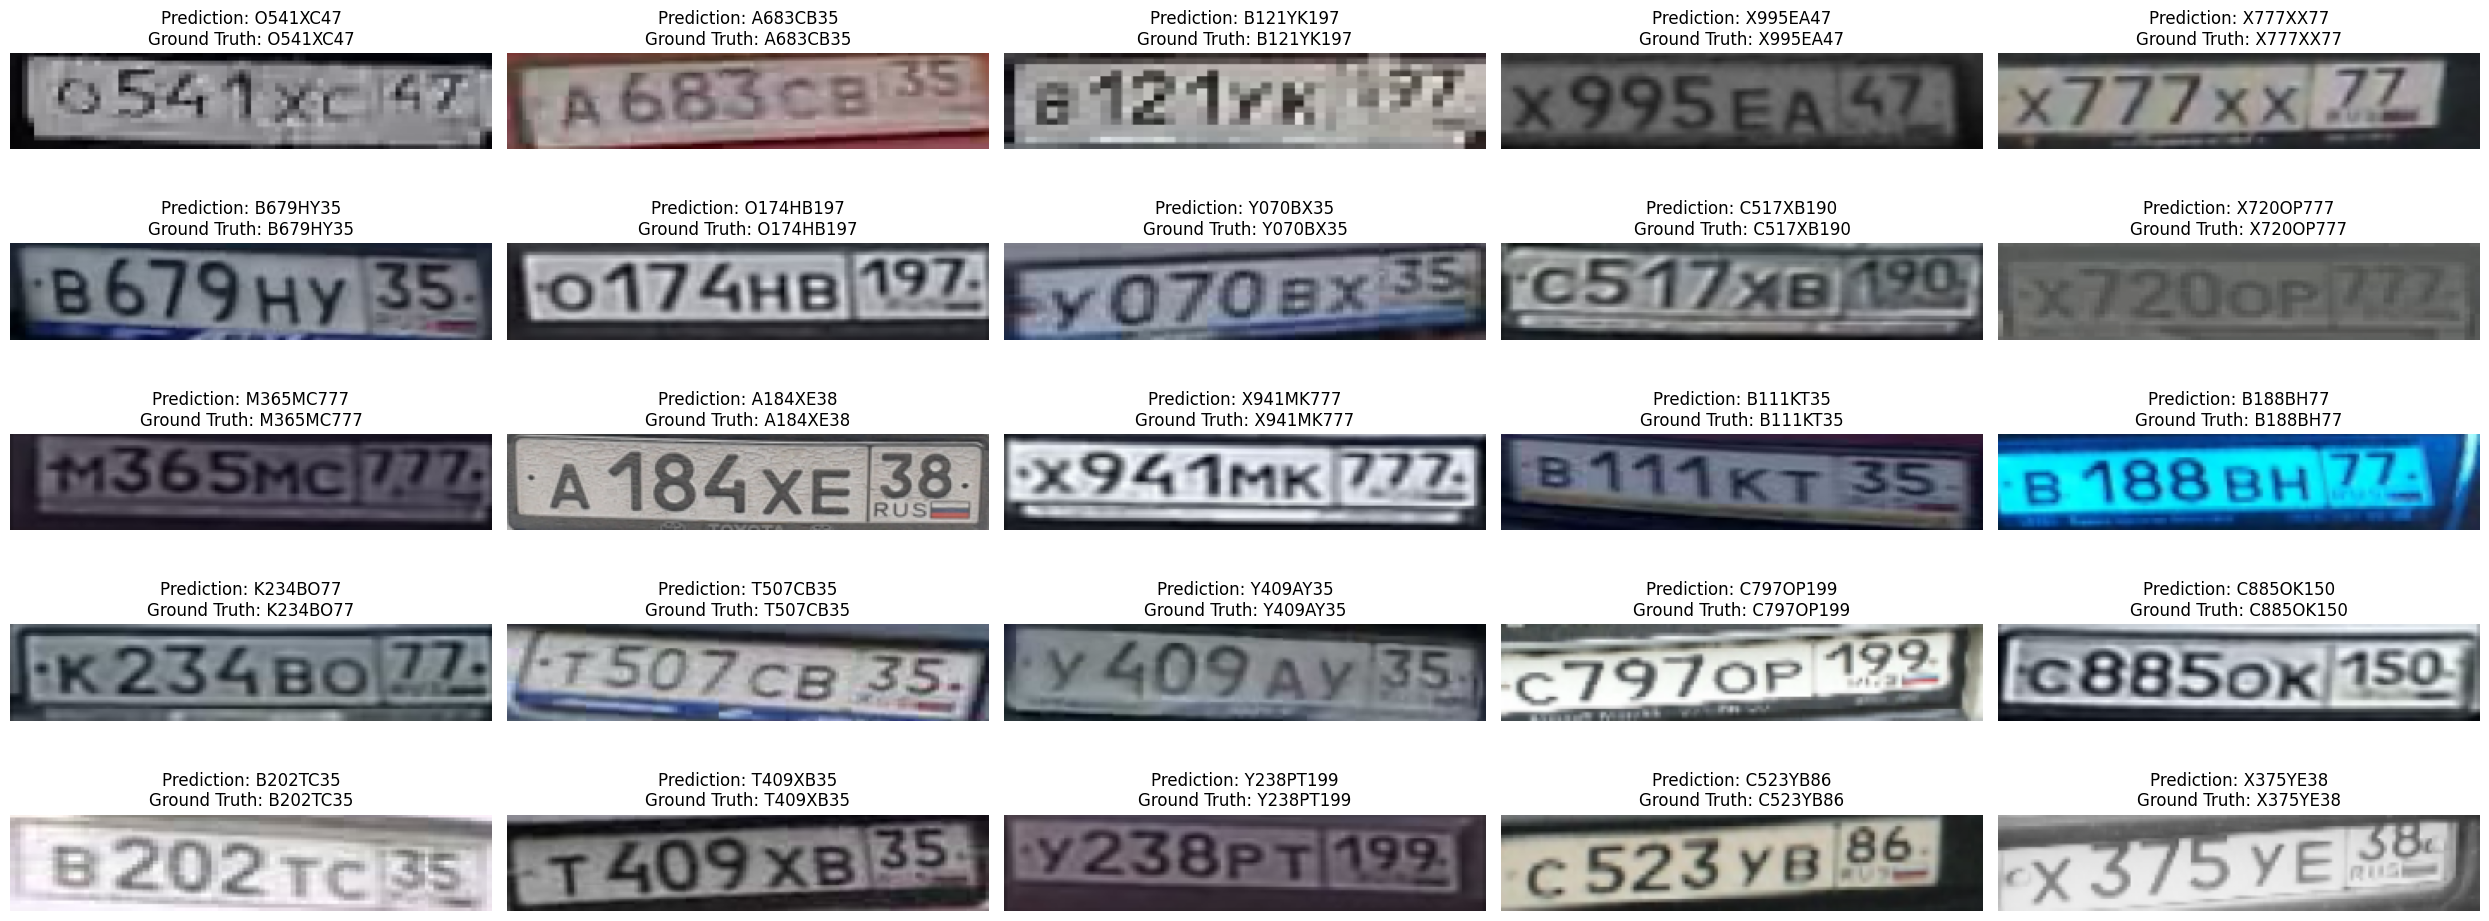

In [38]:
inv_vocab_dict = {v: k for k, v in vocab_dict.items()}
def detokenize(seq, vocab_dict, ignore_tokens):
    return "".join([vocab_dict[i] for i in seq.tolist() if i not in ignore_tokens])

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(25, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    image = batch["image"][i].transpose(1, 2, 0) / 2 + 0.5
    decoded_seq = detokenize(seqs[i], inv_vocab_dict, [vocab_dict["<bos>"], vocab_dict["<eos>"]])
    gt_seq = detokenize(batch["label"][i], inv_vocab_dict, [vocab_dict["<bos>"], vocab_dict["<eos>"]])
    ax.imshow(image)
    ax.set_title(f"Prediction: {decoded_seq}\nGround Truth: {gt_seq}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Лог Экспериментов

| Experiment Name                    | val/loss | val/distance_beam_search | val/distance_fair | val/distance_greedy | val/accuracy_beam_search | val/accuracy_fair | val/accuracy_greedy |
|------------------------------------|----------|--------------------------|-------------------|---------------------|--------------------------|-------------------|---------------------|
| baseline                           | 0.082    | 0.1357                   | 0.1565            | 0.1406              | 0.9172                   | 0.9146            | 0.9214              |
| higher_dropout_weight_decay        | 0.0773   | 0.1189                   | 0.1372            | 0.1213              | 0.9324                   | 0.9192            | 0.9314              |
| stronger_augmentations             | 0.0581   | 0.07788                  | 0.104             | 0.08057             | 0.9524                   | 0.9431            | 0.9514              |
| rnn_encoder                        | 0.136    | 0.4897                   | 0.6355            | 0.5256              | 0.8176                   | 0.7676            | 0.8081              |